# Imports

In [1]:
import random
import albumentations as A
from torch.utils.data import DataLoader
from segmentation_models_pytorch.losses import DiceLoss, SoftBCEWithLogitsLoss, JaccardLoss, FocalLoss

# Custom Library
import ActivationPrototypes_SARSeg.thesis_utils as utils
from ActivationPrototypes_SARSeg.thesis_utils import *

initialized = False

f:\Thesis\.conda\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-04-25 10:24:20.551 | INFO     | ActivationPrototypes_SARSeg.config:<module>:11 - PROJ_ROOT path is: F:\Thesis\ActivationPrototypes_SARSeg


# Setup

In [2]:
from importlib import reload
reload(utils)
from ActivationPrototypes_SARSeg.thesis_utils import *

In [3]:
lmdb_path = '../data/Encoded-BigEarthNet'
parquet_path = '../data/metadata.parquet'

In [4]:
if not initialized:
    train_matches, val_matches, test_matches = match_keys(parquet_path)
    initialized = True

In [5]:
transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
],is_check_shapes=False)

print(f"Train size: {len(train_matches)}, Val size: {len(val_matches)}, Test size: {len(test_matches)}")

# Create datasets	
train_dataset = SARSegmentationDataset120(lmdb_path, train_matches[:], transform=transform)
val_dataset = SARSegmentationDataset120(lmdb_path, val_matches[:], transform=None)
test_dataset = SARSegmentationDataset120(lmdb_path, test_matches[:], transform=None)

# Create data loaders
batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

#Define the model metrcis and load model. 
num_train_img = len(train_dataset)
num_val_img = len(val_dataset)
num_test_img = len(test_dataset)

steps_per_epoch = num_train_img//batch_size
val_steps_per_epoch = num_val_img//batch_size
print("Steps per epoch: ", steps_per_epoch)
print("Validation steps per epoch: ", val_steps_per_epoch)

Train size: 237871, Val size: 122342, Test size: 119825
Opening LMDB environment ...
Opening LMDB environment ...
Opening LMDB environment ...
Steps per epoch:  14866
Validation steps per epoch:  7646


In [6]:
random.seed(42)
random_indices_train = random.sample(range(len(train_matches)), 10000)
random_indices_val = random.sample(range(len(val_matches)), 4000)
random_indices_test = random.sample(range(len(test_matches)), 4000)

random_train_matches = [train_matches[i] for i in random_indices_train]
random_val_matches = [val_matches[i] for i in random_indices_val]
random_test_matches = [test_matches[i] for i in random_indices_test]

train_dataset_short = SARSegmentationDataset120(lmdb_path, random_train_matches[:], transform=transform)
val_dataset_short = SARSegmentationDataset120(lmdb_path, random_val_matches[:], transform=None)
test_dataset_short = SARSegmentationDataset120(lmdb_path, random_test_matches[:], transform=None)

train_loader_short = DataLoader(train_dataset_short, batch_size=batch_size, shuffle=True)
val_loader_short = DataLoader(val_dataset_short, batch_size=batch_size, shuffle=False)
test_loader_short = DataLoader(test_dataset_short, batch_size=batch_size, shuffle=False)

Opening LMDB environment ...
Opening LMDB environment ...
Opening LMDB environment ...


## Tensorflow Board

In [7]:
# %load_ext tensorboard
%reload_ext tensorboard
%tensorboard --logdir=runs --port=6010

Launching TensorBoard...

# Training

In [11]:
from importlib import reload
reload(utils)
from ActivationPrototypes_SARSeg.thesis_utils import *

In [12]:
random.seed(42)
want_to_train120 = True

# model = create_base_model_skipconn()
model = load_base_with_bigearth_pretrained_skipconn()

#print(model)
# model = load_from_checkpoint120("../models/unet120_full_skipconn_epoch_1.pth")

# Freeze encoder layers
for param in model.encoder.parameters():
    param.requires_grad = False
    
if want_to_train120:
    criterion_base = FocalLoss(mode='multiclass', ignore_index=20)  
    # model = create_base_model()
    model, optimizer = training(
        model = model, 
        epoch_start = 1,
        epoch_end =  20,
        # loss_fn = criterion_base,
        train_loader = train_loader,
        val_loader = val_loader,
        num_classes = 20,
        lr = 1e-4,
        model_name = "unet120_full_skipconn",)

else:
    print("Not training")

CustomUnet initialized with encoder channels: (2, 64, 256, 512, 1024, 2048)


Epoch 1/20: 100%|██████████| 14867/14867 [27:27<00:00,  9.03batch/s, f1=0.49, iou=0.33, loss=4.35, lr=0.0001]  


Epoch 1, Train Loss: 4.3537, IoU: 0.3298, F1: 0.4904


Validation: 100%|██████████| 7647/7647 [09:27<00:00, 13.48batch/s, f1=0.519, iou=0.387, loss=3.94, lr=0.0001]


Epoch 1, Val Loss: 3.9437, IoU: 0.3870, F1: 0.5187
 Learning rate after epoch 1: 0.0001


...

Epoch 19, Val Loss: 3.8927, IoU: 0.4769, F1: 0.6185
 Learning rate after epoch 19: 2.5e-05


Epoch 20/20: 100%|██████████| 14867/14867 [30:03<00:00,  8.24batch/s, f1=0.657, iou=0.493, loss=4.26, lr=2.5e-5]


Epoch 20, Train Loss: 4.2576, IoU: 0.4935, F1: 0.6571


Validation: 100%|██████████| 7647/7647 [09:29<00:00, 13.43batch/s, f1=0.618, iou=0.476, loss=3.89, lr=2.5e-5]


Epoch 20, Val Loss: 3.8934, IoU: 0.4758, F1: 0.6175
 Learning rate after epoch 20: 2.5e-05
Last used learning rate: 2.5e-05


In [5]:
# model = load_from_checkpointSkipConn("../models/unet120_full_skipconn_best.pth")
# model.eval()
model_activations = load_from_checkpoint_skipconn("../models/unet120_full_skipconn_best.pth")  # Modify this with your actual model loading function
model_activations.eval();

CustomUnet initialized with encoder channels: (2, 64, 256, 512, 1024, 2048)


In [40]:
model.eval()

CustomUnetSkipConn(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(2, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequ

f:\Thesis\.conda\lib\site-packages\torch\nn\modules\module.py:1739: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


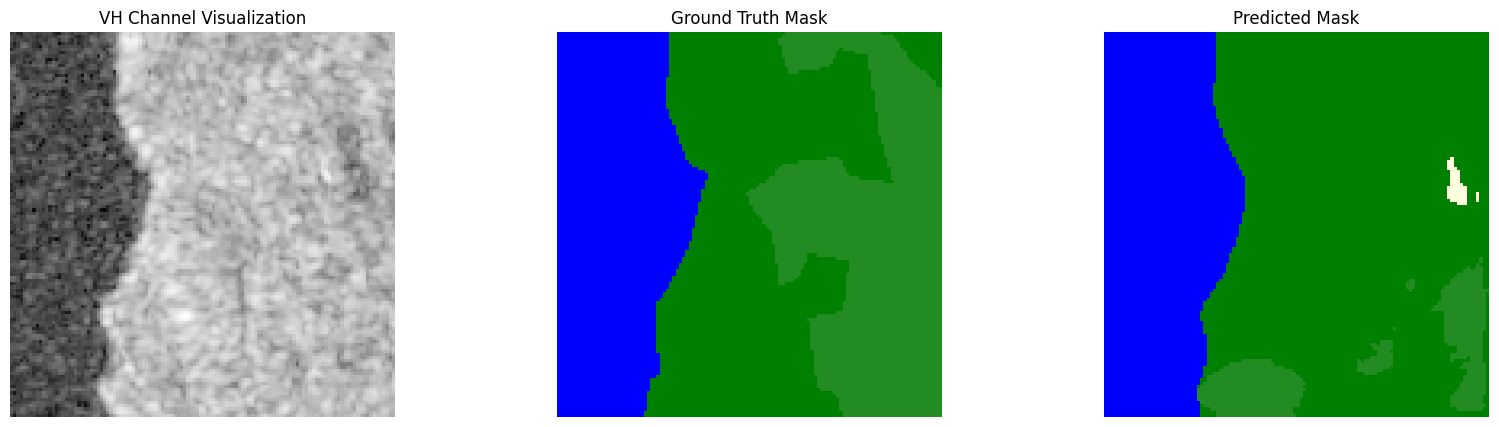

In [46]:
query_image_reference = 'S1B_IW_GRDH_1SDV_20180517T154802_35VNJ_55_62'
query_layer_name = 'encoder.layer4'  # Change to the layer you're analyzing

display_good_bad(model,
                 lmdb_path,
                 "S1B_IW_GRDH_1SDV_20180517T154802_35VNJ_55_62",
                 "S2B_MSIL2A_20180515T094029_N9999_R036_T35VNJ_55_62_reference_map",
                 img_size= 120)


CustomUnet initialized with encoder channels: (2, 64, 256, 512, 1024, 2048)


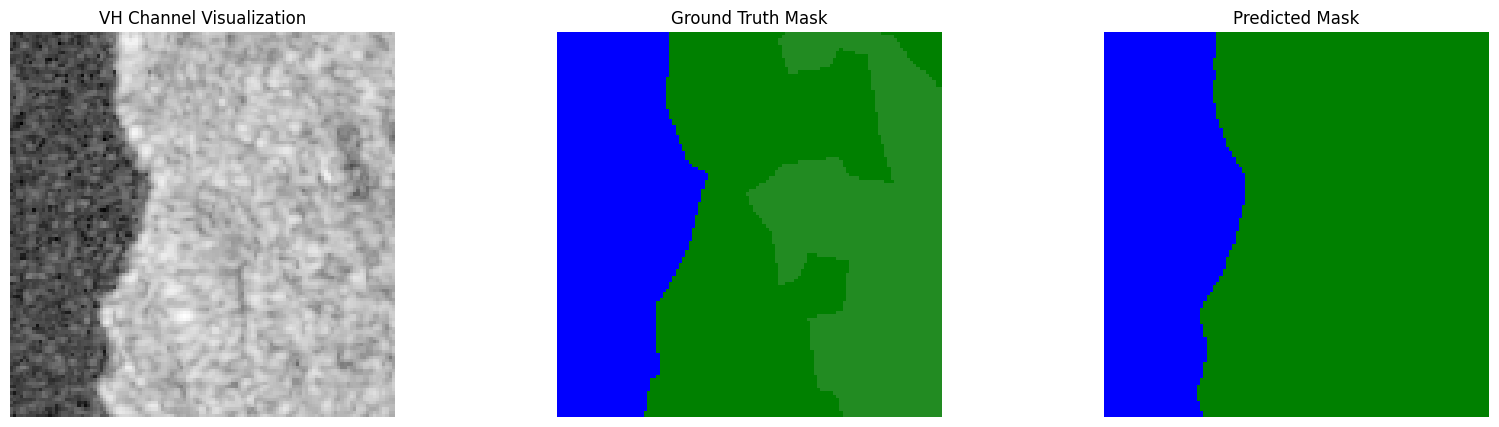

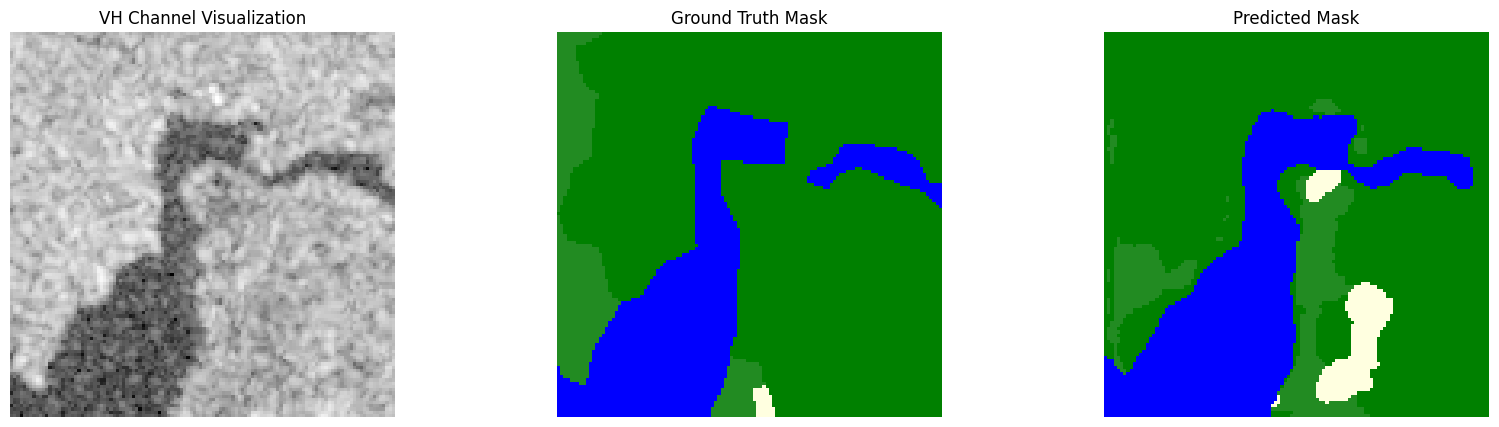

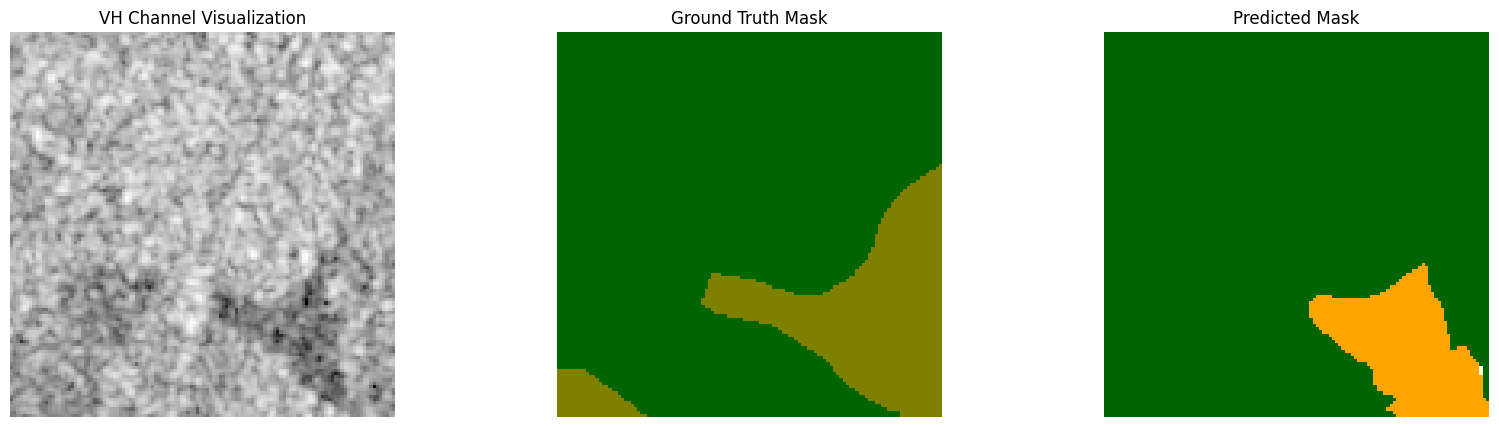

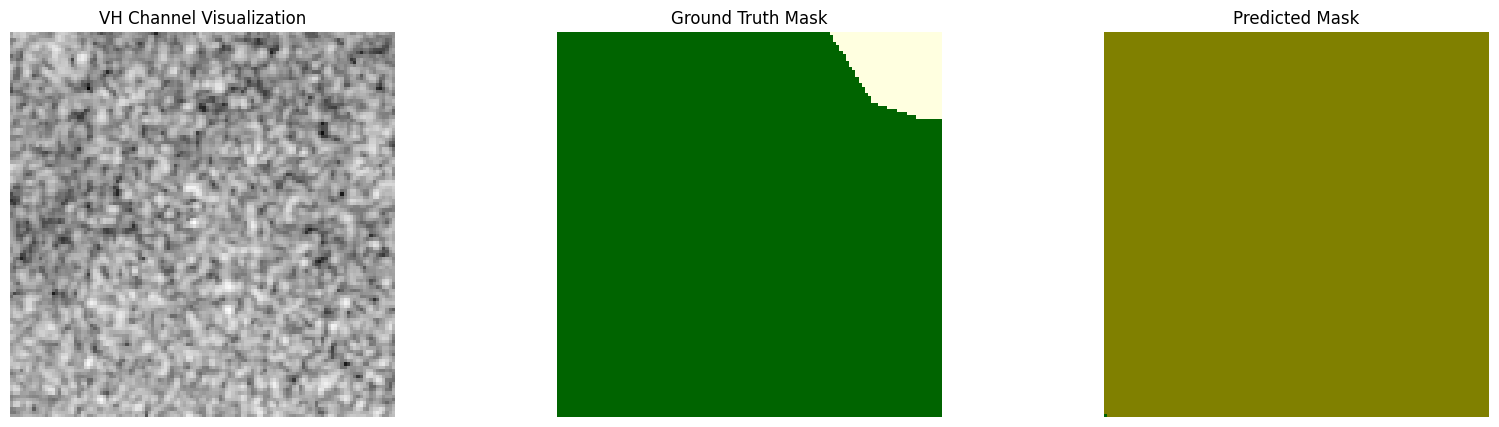

In [17]:
model_activations = load_from_checkpoint_skipconn("../models/unet120_full_skipconn_epoch_18.pth")  # Modify this with your actual model loading function
model_activations.eval()
# Good
display_good_bad(model_activations, lmdb_path, "S1B_IW_GRDH_1SDV_20180517T154802_35VNJ_55_62", "S2B_MSIL2A_20180515T094029_N9999_R036_T35VNJ_55_62_reference_map", img_size= 120)
display_good_bad(model_activations, lmdb_path, "S1A_IW_GRDH_1SDV_20180526T045642_34WFU_35_21", "S2A_MSIL2A_20180526T100031_N9999_R122_T34WFU_35_21_reference_map", img_size= 120)

# Bad ? 
display_good_bad(model_activations, lmdb_path, "S1B_IW_GRDH_1SDV_20180515T063421_29SNC_25_84", "S2B_MSIL2A_20180515T112109_N9999_R037_T29SNC_25_84_reference_map", img_size= 120)
display_good_bad(model_activations, lmdb_path, "S1B_IW_GRDH_1SDV_20180515T063421_29SNC_44_47", "S2B_MSIL2A_20180515T112109_N9999_R037_T29SNC_44_47_reference_map", img_size= 120)